# План ноутбука

Здесь протестируем модуль для предобработки данных, а также запустим предобработку всего набора данных для обучения и тестирования модели


# Шаг 0. Установка и импорт библиотек

In [ ]:
%pip install monai[all] itk-core pydicom nibabel SimpleITK

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "/kernel/lib/python3.10/site-packages/pip/_internal/cli/base_command.py", line 105, in _run_wrapper
    status = _inner_run()
  File "/kernel/lib/python3.10/site-packages/pip/_internal/cli/base_command.py", line 96, in _inner_run
    return self.run(options, args)
  File "/kernel/lib/python3.10/site-packages/pip/_internal/cli/req_command.py", line 68, in wrapper
    return func(self, options, args)
  File "/kernel/lib/python3.10/site-packages/pip/_internal/commands/install.py", line 387, in run
    requirement_set = resolver.resolve(
  File "/kernel/lib/python3.10/site-packages/pip/_internal/resolution/resolvelib/resolver.py", line 96, in resolve
    result = self._result = resolver.r

In [2]:
%pip uninstall -y itk itk-core itk-gdcm pydicom

Found existing installation: itk-core 5.4.4.post1
Uninstalling itk-core-5.4.4.post1:
  Successfully uninstalled itk-core-5.4.4.post1
Found existing installation: pydicom 3.0.1
Uninstalling pydicom-3.0.1:
  Successfully uninstalled pydicom-3.0.1


In [3]:
%pip install -qU itk pydicom


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


Чтобы импортировать модуль, нужно добавить ссыслку на него в path, это можно сделать из командной строки или с помощью sys.path.append, куда нужно передать путь к папке, где находится модуль

In [ ]:
# if not os.getcwd().endswith("chest-ct-classification"):
#     # для перемещения в корень репозитория
#     %cd {os.path.join(os.getcwd(), 'project', 'chest-ct-classification')}

In [1]:
import sys
import os
import pathlib
import pandas as pd
sys.path.append(os.path.join(os.getcwd(), 'project', 'chest-ct-classification', 'src', 'CTPreprocessor'))  

# импортируем
from ct_preprocessor import PreprocConfig, MedPreprocessor

Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
2025-09-28 12:14:05.726692: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-28 12:14:05.787394: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the

In [2]:
# установим рабочую директорию
work_dir = os.path.join(os.path.expanduser('~'), 'work', 'data')

%cd {work_dir}

/home/jupyter/work/data


In [5]:
directory_path =  pathlib.Path("dataset_subset/normal/nifti_studies") 

# Получаем список только файлов, используя .iterdir() и .is_file()
file_list = [entry for entry in directory_path.iterdir()]

for i in file_list: print(i)

dataset_subset/normal/nifti_studies/study_0001.nii.gz
dataset_subset/normal/nifti_studies/study_0002.nii.gz
dataset_subset/normal/nifti_studies/study_0003.nii.gz
dataset_subset/normal/nifti_studies/study_0004.nii.gz
dataset_subset/normal/nifti_studies/study_0005.nii.gz
dataset_subset/normal/nifti_studies/study_0006.nii.gz
dataset_subset/normal/nifti_studies/study_0007.nii.gz
dataset_subset/normal/nifti_studies/study_0008.nii.gz
dataset_subset/normal/nifti_studies/study_0009.nii.gz
dataset_subset/normal/nifti_studies/study_0010.nii.gz
dataset_subset/normal/nifti_studies/study_0011.nii.gz
dataset_subset/normal/nifti_studies/study_0012.nii.gz
dataset_subset/normal/nifti_studies/study_0013.nii.gz
dataset_subset/normal/nifti_studies/study_0014.nii.gz
dataset_subset/normal/nifti_studies/study_0015.nii.gz
dataset_subset/normal/nifti_studies/study_0016.nii.gz
dataset_subset/normal/nifti_studies/study_0017.nii.gz
dataset_subset/normal/nifti_studies/study_0018.nii.gz
dataset_subset/normal/nifti_

# Поиск метаданных у nifti-данных

Логика, реализуемая в модуле почему-то не находит данные о параметрах вокселя для nifti-томов, поэтому попробуем разные способы загрузки и попробуем вытащить метаинформацию и затем исправим модуль

In [6]:
# ================================
# ДЕТАЛЬНАЯ ПРОВЕРКА NIFTI МЕТАДАННЫХ
# ================================

import nibabel as nib
import numpy as np
from pathlib import Path
import SimpleITK as sitk

def analyze_nifti_metadata(filepath):
    """Детальный анализ метаданных NIfTI файла"""
    
    print(f"🔍 АНАЛИЗ NIFTI: {Path(filepath).name}")
    print("="*70)
    
    # 1. ЧЕРЕЗ NIBABEL
    print("📋 1. АНАЛИЗ ЧЕРЕЗ NIBABEL:")
    try:
        nii = nib.load(filepath)
        
        print(f"   📊 Размер данных: {nii.shape}")
        print(f"   🔢 Тип данных: {nii.get_fdata().dtype}")
        print(f"   📐 Affine матрица:")
        print(f"   {nii.affine}")
        
        # Извлечение spacing из affine
        spacing_from_affine = np.sqrt(np.sum(nii.affine[:3,:3]**2, axis=0))
        print(f"   📏 Spacing из affine: {spacing_from_affine}")
        
        # Header информация
        header = nii.header
        print(f"   📋 Доступные поля header: {list(header.keys())[:10]}...")
        
        # Pixdim - важное поле для spacing
        if 'pixdim' in header:
            pixdim = header['pixdim']
            print(f"   🎯 Pixdim (spacing): {pixdim[1:4]}")  # [1:4] потому что 0-й элемент не spacing
        
        # Qform и Sform коды
        print(f"   🔄 Qform code: {header.get('qform_code', 'НЕТ')}")
        print(f"   🔄 Sform code: {header.get('sform_code', 'НЕТ')}")
        
        # Диапазон значений
        data = nii.get_fdata()
        print(f"   📊 Диапазон значений: [{data.min():.1f}, {data.max():.1f}]")
        
    except Exception as e:
        print(f"   ❌ Ошибка nibabel: {e}")
    
    # 2. ЧЕРЕЗ SimpleITK
    print(f"\n📋 2. АНАЛИЗ ЧЕРЕЗ SimpleITK:")
    try:
        sitk_img = sitk.ReadImage(str(filepath))
        
        print(f"   📊 Размер: {sitk_img.GetSize()}")
        print(f"   📏 Spacing: {sitk_img.GetSpacing()}")
        print(f"   🎯 Origin: {sitk_img.GetOrigin()}")
        print(f"   🔄 Direction: {sitk_img.GetDirection()[:3]}")  # первые 3 элемента
        print(f"   🔢 Тип пикселей: {sitk_img.GetPixelIDTypeAsString()}")
        
        # Конвертация в numpy
        array = sitk.GetArrayFromImage(sitk_img)
        print(f"   📊 Array shape: {array.shape}")
        print(f"   📊 Array диапазон: [{array.min():.1f}, {array.max():.1f}]")
        
    except Exception as e:
        print(f"   ❌ Ошибка SimpleITK: {e}")
    
    # 3. ЧЕРЕЗ MONAI
    print(f"\n📋 3. АНАЛИЗ ЧЕРЕЗ MONAI:")
    try:
        from monai.transforms import LoadImaged, EnsureChannelFirstd
        
        loader = LoadImaged(keys=["image"], image_only=False)
        data = {"image": str(filepath)}
        result = loader(data)
        
        volume = result["image"]
        print(f"   📊 MONAI volume shape: {volume.shape}")
        print(f"   🔢 MONAI dtype: {volume.dtype}")
        
        # Метаданные MONAI
        if hasattr(volume, 'meta'):
            meta = volume.meta
            print(f"   📋 MONAI мета поля: {list(meta.keys())}")
            
            if 'spacing' in meta:
                print(f"   📏 MONAI spacing: {meta['spacing']}")
            else:
                print(f"   ⚠️ MONAI НЕТ spacing в метаданных")
                
            if 'affine' in meta:
                print(f"   📐 MONAI affine shape: {meta['affine'].shape}")
            else:
                print(f"   ⚠️ MONAI НЕТ affine в метаданных")
        else:
            print(f"   ⚠️ MONAI НЕТ метаданных вообще")
            
    except Exception as e:
        print(f"   ❌ Ошибка MONAI: {e}")
    
    print("\n" + "="*70)


In [7]:
# Проверим несколько файлов из разных папок
test_files = [
    "dataset_subset/normal/nifti_studies/study_0044.nii.gz",
    "dataset_subset/normal/nifti_studies/study_0045.nii.gz",
    "dataset_subset/normal/nifti_studies/study_0046.nii.gz",
    "dataset_subset/normal/nifti_studies/study_0047.nii.gz",
    "dataset_subset/normal/nifti_studies/study_0048.nii.gz",
    "dataset_subset/normal/nifti_studies/study_0049.nii.gz",
    "dataset_subset/normal/nifti_studies/study_0050.nii.gz"
]

for filepath in test_files:
    if Path(filepath).exists():
        analyze_nifti_metadata(filepath)
        print("\n" + "🔹"*50 + "\n")


🔍 АНАЛИЗ NIFTI: study_0044.nii.gz
📋 1. АНАЛИЗ ЧЕРЕЗ NIBABEL:
   📊 Размер данных: (512, 512, 40)
   🔢 Тип данных: float64
   📐 Affine матрица:
   [[-6.21999979e-01  0.00000000e+00 -0.00000000e+00  1.73126007e+02]
 [-0.00000000e+00  6.21999979e-01 -0.00000000e+00 -1.86122086e+02]
 [ 0.00000000e+00  0.00000000e+00  8.00000000e+00 -9.43299927e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
   📏 Spacing из affine: [0.62199998 0.62199998 8.        ]
   📋 Доступные поля header: ['sizeof_hdr', 'data_type', 'db_name', 'extents', 'session_error', 'regular', 'dim_info', 'dim', 'intent_p1', 'intent_p2']...
   🎯 Pixdim (spacing): [0.622 0.622 8.   ]
   🔄 Qform code: 1
   🔄 Sform code: 1
   📊 Диапазон значений: [-2048.0, 1851.0]

📋 2. АНАЛИЗ ЧЕРЕЗ SimpleITK:
   📊 Размер: (512, 512, 40)
   📏 Spacing: (0.621999979019165, 0.621999979019165, 8.0)
   🎯 Origin: (-173.12600708007812, 186.12208557128906, -943.2999267578125)
   🔄 Direction: (1.0, 0.0, 0.0)
   🔢 Тип пикселей: 16-bit s

# Тест модуля

In [3]:
# ================================
# ИМПОРТ ФИНАЛЬНОГО МОДУЛЯ
# ================================
import sys
from pathlib import Path
import torch
import gc

# Импорт финального модуля
# (сохраните код выше как ct_preprocessor_final.py)
from ct_preprocessor import PreprocConfig, MedPreprocessor

print("✅ Финальный модуль импортирован")
print(f"PyTorch: {torch.__version__}")
#print(f"CUDA: {torch.cuda.is_available()}")


✅ Финальный модуль импортирован
PyTorch: 2.8.0+cu128


In [6]:
# ================================
# ФИНАЛЬНАЯ КОНФИГУРАЦИЯ
# ================================

# УСТАНОВИТЕ СВОЙ ПУТЬ
YOUR_DATA_PATH = '/home/jupyter/work/data/dataset_subset/test_subset_small'  # ИЗМЕНИТЕ НА СВОЙ ПУТЬ
OUTPUT_PATH = '/home/jupyter/work/data/preproc'

# Финальная проверенная конфигурация
final_config = PreprocConfig(
    input_root=YOUR_DATA_PATH,
    preproc_root=OUTPUT_PATH,
    
    # Умеренные параметры для надежности
    target_pixdim=(1.0, 1.0, 8),    # Не слишком агрессивный ресэмплинг
    target_size=(128, 128, 64),         # Разумный размер
    hu_window=(-1000.0, 400.0),       # Стандартное легочное окно
    padding_value=-2048.0,            # Обработка padding
    
    # ЛИБЕРАЛЬНЫЕ QA настройки (основаны на опыте)
    enable_qa=True,
    min_depth=16,                     # Минимум 16 срезов
    max_clip_share=0.95,             # 95% клиппинга OK
    max_padding_share=0.90,          # 90% воздуха OK
    
    # Отключенные фильтры (для максимальной совместимости)
    enable_dicom_filters=False,
    reject_localizer=False,
    require_ct_modality=False,
    
    # Производительность
    n_procs=4,                       # Консервативно для стабильности
    overwrite=True,
    
    # Подробное логирование
    enable_logging=True,
    log_level="INFO",
    pipeline_version="v3.0_final",
)

print("🔧 Финальная конфигурация готова")
print(f"   📂 Вход: {final_config.input_root}")
print(f"   📁 Выход: {final_config.preproc_root}")
print(f"   📏 Размер: {final_config.target_size}")
print(f"   📏 Размер вокселя: {final_config.target_pixdim}")
print(f"   🔍 QA: {'включена' if final_config.enable_qa else 'отключена'}")

🔧 Финальная конфигурация готова
   📂 Вход: /home/jupyter/work/data/dataset_subset/test_subset_small
   📁 Выход: /home/jupyter/work/data/preproc
   📏 Размер: (128, 128, 64)
   📏 Размер вокселя: (1.0, 1.0, 8)
   🔍 QA: включена


In [7]:
# ================================
# ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ
# ================================

print("🚀 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ")
print("="*50)

# Создание процессора
final_processor = MedPreprocessor(final_config)

# Запуск полного препроцессинга
print("🔄 Запуск препроцессинга...")
final_results = final_processor.build()

# Детальный анализ результатов
successful = sum(1 for r in final_results if r.get("ok", False))
cached = sum(1 for r in final_results if r.get("cached", False))
failed = len(final_results) - successful

print(f"\n📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print(f"   ✅ Успешно: {successful}")
print(f"   💾 Из кэша: {cached}")
print(f"   ❌ Ошибок: {failed}")
print(f"   📈 Успешность: {successful/len(final_results)*100 if final_results else 0:.1f}%")

# Анализ типов ошибок
if failed > 0:
    print(f"\n🔍 АНАЛИЗ ОШИБОК:")
    error_types = {}
    for result in final_results:
        if not result.get("ok", False):
            reason = result.get("reason", "unknown")
            error_types[reason] = error_types.get(reason, 0) + 1
    
    for reason, count in error_types.items():
        print(f"   {reason}: {count}")

# Тестирование DataLoader
if successful > 0:
    print(f"\n🎯 ТЕСТИРОВАНИЕ DATALOADER:")
    try:
        train_loader = final_processor.get_dataloader(
            batch_size=2,
            num_workers=4,
            shuffle=True
        )
        
        print(f"   ✅ DataLoader создан: {len(train_loader)} батчей")
        
        # Тест первого батча
        for batch in train_loader:
            image = batch["image"]
            print(f"   📊 Батч: {image.shape}")
            print(f"   🔢 Тип: {image.dtype}")
            print(f"   📏 Диапазон: [{image.min():.3f}, {image.max():.3f}]")
            
            # Проверки
            assert image.shape[0] <= 2, "Размер батча"
            assert len(image.shape) == 5, "Размерность"
            assert 0.0 <= image.min() and image.max() <= 1.0, "Диапазон значений"
            
            print(f"   ✅ Все проверки пройдены!")
            break
            
    except Exception as e:
        print(f"   ❌ Ошибка DataLoader: {e}")

print(f"\n🎉 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!")

if successful > 0:
    print(f"✅ СИСТЕМА ГОТОВА К ОБУЧЕНИЮ АВТОЭНКОДЕРА!")
    print(f"   📁 Данные: {final_processor.output_dir}")
    print(f"   📊 Образцов: {successful}")
    print(f"   📏 Размер: {final_config.target_size}")
else:
    print(f"❌ ТРЕБУЕТСЯ ДОПОЛНИТЕЛЬНАЯ НАСТРОЙКА")
    print(f"   Попробуйте:")
    print(f"   - enable_qa=False")
    print(f"   - Другие пути к данным")
    print(f"   - Проверить формат файлов")


🚀 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ


2025-09-28 12:16:36,640 - MedPreprocessor - INFO - 🚀 MedPreprocessor v3.0 инициализирован
2025-09-28 12:16:36,641 - MedPreprocessor - INFO -    📂 /home/jupyter/work/data/dataset_subset/test_subset_small
2025-09-28 12:16:36,642 - MedPreprocessor - INFO -    📁 /home/jupyter/work/data/preproc/820e13157c21
2025-09-28 12:16:36,644 - MedPreprocessor - INFO - 🔍 Обнаружение данных...
2025-09-28 12:16:36,645 - MedPreprocessor - INFO - 🔍 Сканирование: /home/jupyter/work/data/dataset_subset/test_subset_small
2025-09-28 12:16:36,649 - MedPreprocessor - INFO - 📁 Поиск NIfTI...


🔄 Запуск препроцессинга...


2025-09-28 12:16:37,287 - MedPreprocessor - INFO -   ✅ NIfTI: 10
2025-09-28 12:16:37,288 - MedPreprocessor - INFO - 📁 Поиск DICOM...
2025-09-28 12:16:39,611 - MedPreprocessor - INFO -   ✅ DICOM: 6
2025-09-28 12:16:39,612 - MedPreprocessor - INFO - 🎯 Всего: 16
2025-09-28 12:16:39,613 - MedPreprocessor - INFO - 📊 К обработке: 16
Обработка:   0%|          | 0/16 [00:00<?, ?it/s]

  🔍 Вход: torch.Size([1, 1, 512, 512, 35]), мета: 43
  🔍 Вход: torch.Size([1, 1, 512, 512, 40]), мета: 43
  🔍 Вход: torch.Size([1, 1, 512, 512, 39]), мета: 43
  🔍 Вход: torch.Size([1, 1, 512, 512, 43]), мета: 43
  🔄 Заменено padding: 1968820 вокселей
  📏 Найденный spacing: [0.7820000052452087, 0.7820000052452087, 8.0]  🔄 Заменено padding: 2250080 вокселей

  📏 Ресэмплинг: [0.7820000052452087, 0.7820000052452087, 8.0] -> (1.0, 1.0, 8)
  🔄 Заменено padding: 2193828 вокселей
  📏 Найденный spacing: [0.7820000052452087, 0.7820000052452087, 8.0]
  📏 Ресэмплинг: [0.7820000052452087, 0.7820000052452087, 8.0] -> (1.0, 1.0, 8)
  📏 Найденный spacing: [0.7319999933242798, 0.7319999933242798, 8.0]  🔄 Заменено padding: 2418836 вокселей

  📏 Ресэмплинг: [0.7319999933242798, 0.7319999933242798, 8.0] -> (1.0, 1.0, 8)
  📏 Найденный spacing: [0.621999979019165, 0.621999979019165, 8.0]
  📏 Ресэмплинг: [0.621999979019165, 0.621999979019165, 8.0] -> (1.0, 1.0, 8)
  ✅ Ресэмплинг выполнен: torch.Size([1, 1, 4

...

  ✅ Ресэмплинг выполнен: torch.Size([1, 1, 345, 345, 42])
  📐 Resize: torch.Size([345, 345, 42]) -> (128, 128, 64)


Обработка:  88%|████████▊ | 14/16 [00:19<00:04,  2.04s/it]

  ✅ Ресэмплинг выполнен: torch.Size([1, 1, 303, 303, 33])
  📐 Resize: torch.Size([303, 303, 33]) -> (128, 128, 64)
  ✅ Ресэмплинг выполнен: torch.Size([1, 1, 400, 400, 45])
  📐 Resize: torch.Size([400, 400, 45]) -> (128, 128, 64)


Обработка: 100%|██████████| 16/16 [00:21<00:00,  1.35s/it]
2025-09-28 12:17:01,379 - MedPreprocessor - INFO - ✅ Завершено:
2025-09-28 12:17:01,380 - MedPreprocessor - INFO -    📊 Успешно: 16/16
2025-09-28 12:17:01,381 - MedPreprocessor - INFO -    💾 Кэш: 0
2025-09-28 12:17:01,435 - MedPreprocessor - INFO - 📚 DataLoader: 16 файлов



📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
   ✅ Успешно: 16
   💾 Из кэша: 0
   ❌ Ошибок: 0
   📈 Успешность: 100.0%

🎯 ТЕСТИРОВАНИЕ DATALOADER:
   ✅ DataLoader создан: 8 батчей
   📊 Батч: torch.Size([2, 1, 128, 128, 64])
   🔢 Тип: torch.float32
   📏 Диапазон: [0.000, 1.000]
   ✅ Все проверки пройдены!

🎉 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!
✅ СИСТЕМА ГОТОВА К ОБУЧЕНИЮ АВТОЭНКОДЕРА!
   📁 Данные: /home/jupyter/work/data/preproc/820e13157c21
   📊 Образцов: 16
   📏 Размер: (128, 128, 64)


In [8]:
# Проверим все ли на месте
directory_path = Path("preproc/820e13157c21")

# Получаем список только файлов, используя .iterdir() и .is_file()
file_list = [entry for entry in directory_path.iterdir()]

# Выводим имена файлов
for file_path in file_list:
    print(file_path.name)

c8124ccd.nii.gz
28e195bf.nii.gz
1afb539f.nii.gz
f73d261b.nii.gz
c8124ccd.json
28e195bf.json
1afb539f.json
f73d261b.json
ff46b603.nii.gz
c3842cd2.nii.gz
07cd2009.nii.gz
ff46b603.json
aa14c0fb.nii.gz
c3842cd2.json
07cd2009.json
aa14c0fb.json
2af91d07.nii.gz
ed389786.nii.gz
2af91d07.json
ad950838.nii.gz
ed389786.json
ad950838.json
82761269.nii.gz
82761269.json
f645afb0.nii.gz
f645afb0.json
b1a19119.nii.gz
b1a19119.json
ec7b770d.nii.gz
ec7b770d.json
d7924d7c.nii.gz
d7924d7c.json
_index.json


# Посмотрим на предобработанные данные

In [10]:
# ================================
# ВИЗУАЛИЗАЦИЯ ОБРАБОТАННЫХ ДАННЫХ  
# ================================

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

def visualize_processed_ct(nii_path, title="Processed CT"):
    """Визуализация обработанного КТ тома"""
    
    # Загрузка
    nii = nib.load(nii_path)
    volume = nii.get_fdata()
    
    print(f"📊 Размер тома: {volume.shape}")
    print(f"📏 Диапазон значений: [{volume.min():.3f}, {volume.max():.3f}]")
    
    # 3 проекции
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Аксиальные срезы (горизонтальные)
    mid_z = volume.shape[2] // 2
    axes[0,0].imshow(volume[:, :, mid_z], cmap='gray', vmin=0, vmax=1)
    axes[0,0].set_title(f'Аксиальный (Z={mid_z})')
    axes[0,0].axis('off')
    
    axes[1,0].imshow(volume[:, :, mid_z//2], cmap='gray', vmin=0, vmax=1)  
    axes[1,0].set_title(f'Аксиальный (Z={mid_z//2})')
    axes[1,0].axis('off')
    
    # Сагиттальные срезы (боковые)
    mid_x = volume.shape[0] // 2
    axes[0,1].imshow(volume[mid_x, :, :], cmap='gray', vmin=0, vmax=1)
    axes[0,1].set_title(f'Сагиттальный (X={mid_x})')
    axes[0,1].axis('off')
    
    axes[1,1].imshow(volume[mid_x//2, :, :], cmap='gray', vmin=0, vmax=1)
    axes[1,1].set_title(f'Сагиттальный (X={mid_x//2})')  
    axes[1,1].axis('off')
    
    # Корональные срезы (фронтальные)
    mid_y = volume.shape[1] // 2
    axes[0,2].imshow(volume[:, mid_y, :], cmap='gray', vmin=0, vmax=1)
    axes[0,2].set_title(f'Корональный (Y={mid_y})')
    axes[0,2].axis('off')
    
    axes[1,2].imshow(volume[:, mid_y//2, :], cmap='gray', vmin=0, vmax=1)
    axes[1,2].set_title(f'Корональный (Y={mid_y//2})')
    axes[1,2].axis('off')
    
    plt.suptitle(f'{title} - Размер: {volume.shape}')
    plt.tight_layout()
    plt.show()
    
    return volume


🔍 ВИЗУАЛИЗАЦИЯ ОБРАБОТАННЫХ ДАННЫХ
Найдено файлов: 16

📁 ФАЙЛ 1: c8124ccd.nii.gz
📊 Размер тома: (128, 128, 64)
📏 Диапазон значений: [0.000, 1.000]


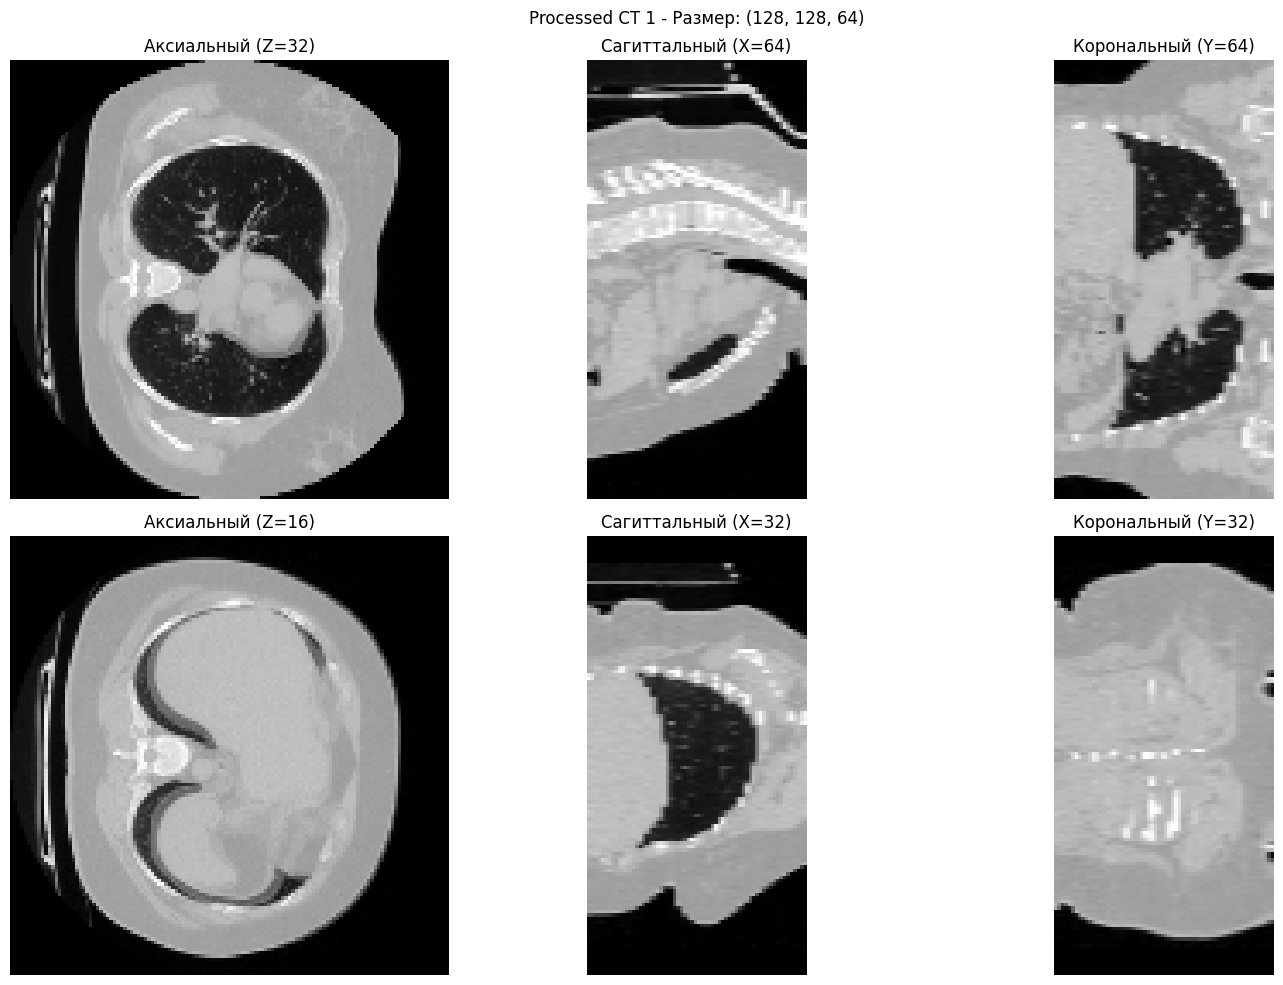

   📊 Уникальных значений: 776698
   🫁 Воздух (0-0.1): 424303
   🦴 Кость (0.8-1.0): 26877
   🩸 Ткани (0.3-0.7): 341783

📁 ФАЙЛ 2: 28e195bf.nii.gz
📊 Размер тома: (128, 128, 64)
📏 Диапазон значений: [0.000, 1.000]


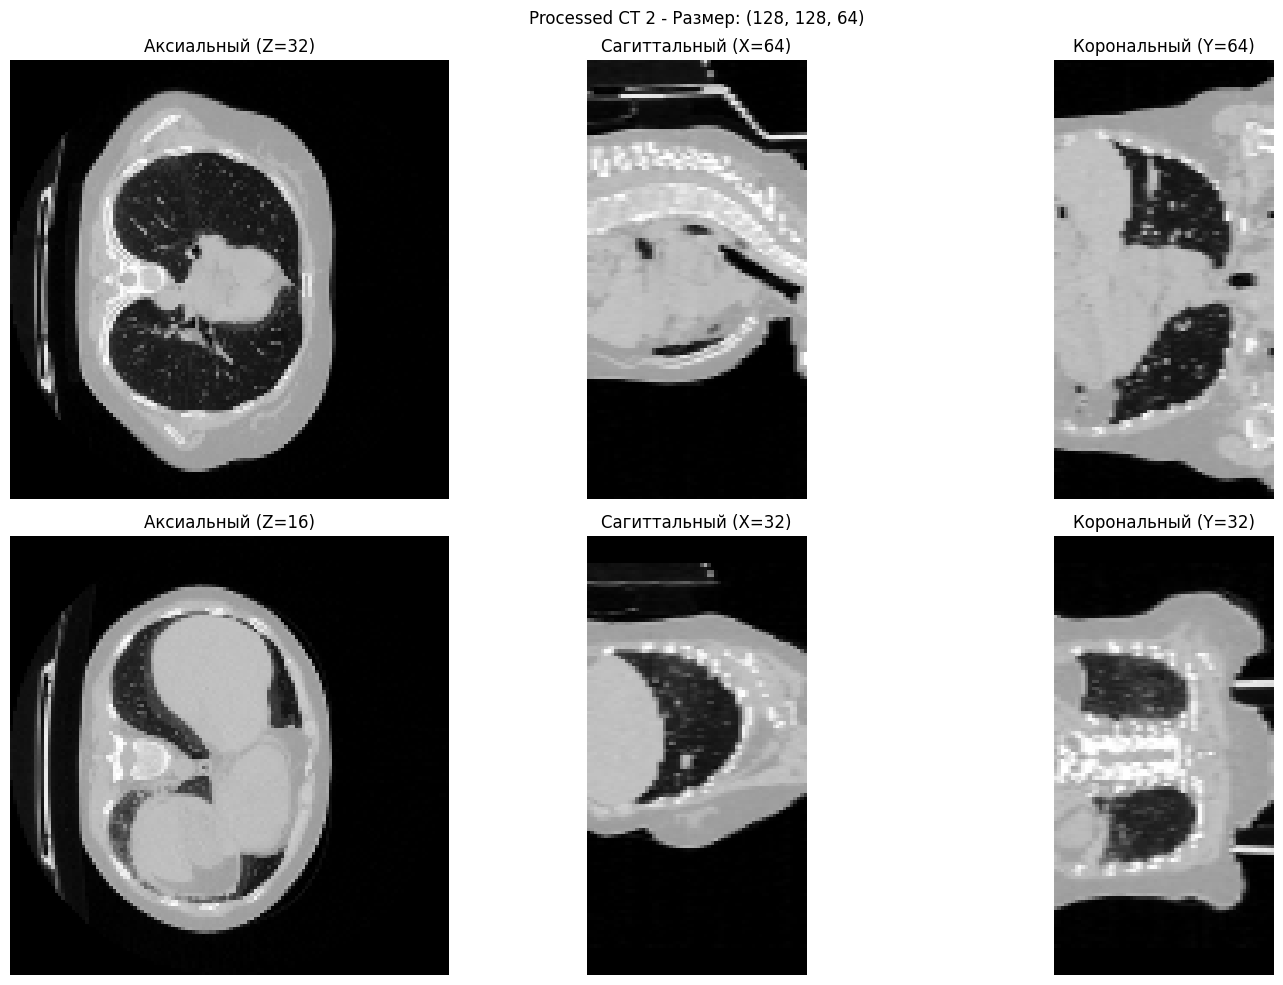

   📊 Уникальных значений: 813458
   🫁 Воздух (0-0.1): 643709
   🦴 Кость (0.8-1.0): 23224
   🩸 Ткани (0.3-0.7): 169582

📁 ФАЙЛ 3: 1afb539f.nii.gz
📊 Размер тома: (128, 128, 64)
📏 Диапазон значений: [0.000, 1.000]


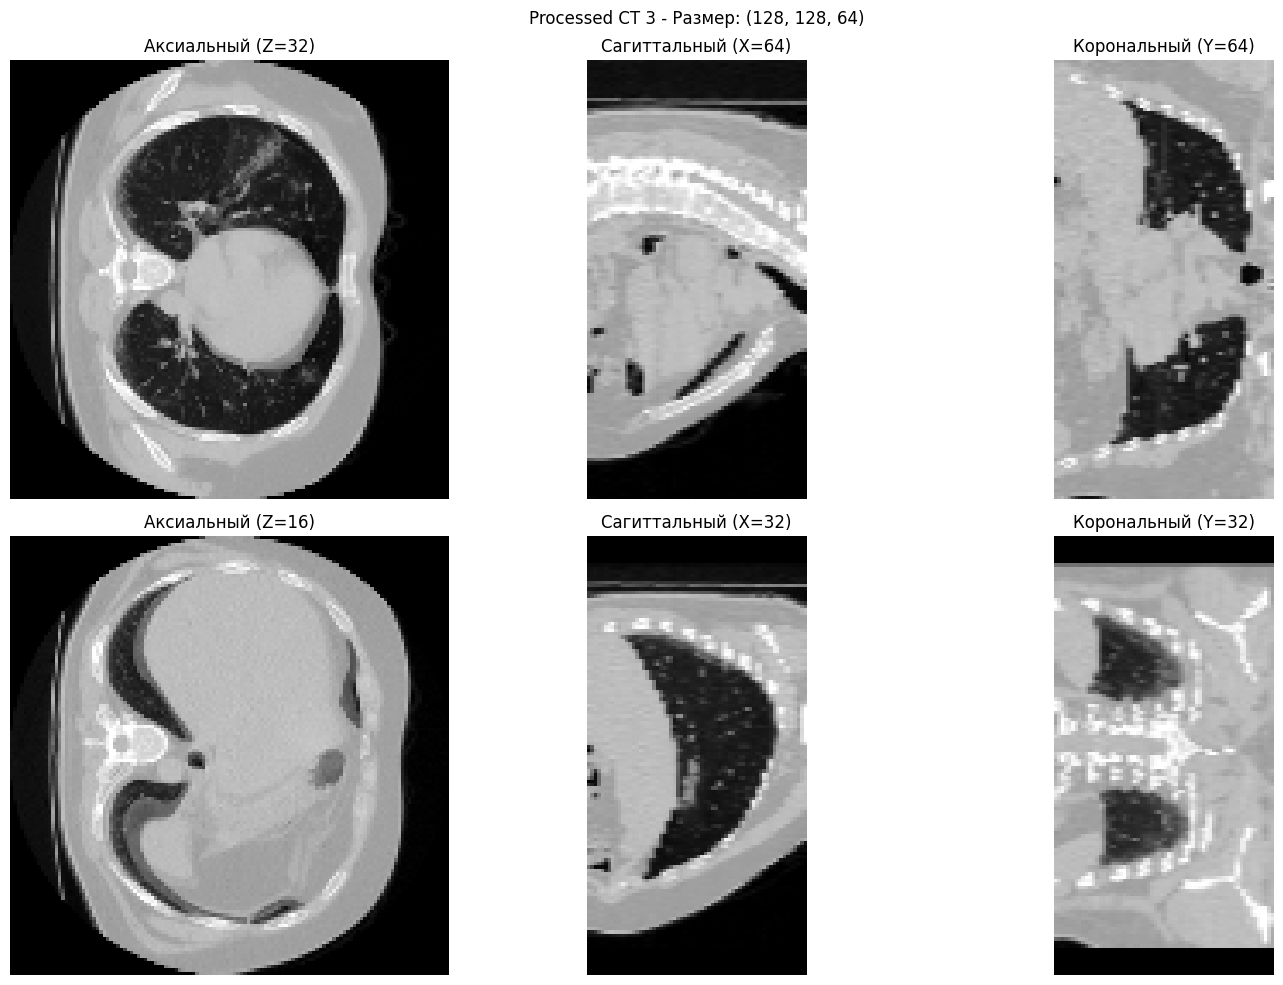

   📊 Уникальных значений: 783191
   🫁 Воздух (0-0.1): 399746
   🦴 Кость (0.8-1.0): 40596
   🩸 Ткани (0.3-0.7): 292644


In [11]:
# Визуализируем несколько обработанных файлов
processed_dir = Path("/home/jupyter/work/data/preproc/820e13157c21")
nii_files = list(processed_dir.glob("*.nii.gz"))

print(f"🔍 ВИЗУАЛИЗАЦИЯ ОБРАБОТАННЫХ ДАННЫХ")
print(f"Найдено файлов: {len(nii_files)}")

for i, nii_file in enumerate(nii_files[:3]):  # первые 3 файла
    print(f"\n📁 ФАЙЛ {i+1}: {nii_file.name}")
    volume = visualize_processed_ct(nii_file, f"Processed CT {i+1}")
    
    # Дополнительная статистика
    print(f"   📊 Уникальных значений: {len(np.unique(volume))}")
    print(f"   🫁 Воздух (0-0.1): {(volume <= 0.1).sum()}")
    print(f"   🦴 Кость (0.8-1.0): {(volume >= 0.8).sum()}")
    print(f"   🩸 Ткани (0.3-0.7): {((volume >= 0.3) & (volume <= 0.7)).sum()}")

# Обработка всех исследований и распределение по папкам

In [ ]:
# ================================
# МАССОВАЯ ОБРАБОТКА ПО КАТЕГОРИЯМ
# ================================

# Пути к данным
DATASET_ROOT = Path("/path/to/your/dataset_subset")  # ИЗМЕНИ
PREPROC_ROOT = Path("./preprocessed_data") # ИЗМЕНИ

def setup_preprocessing_configs():
    """Настройка конфигураций для каждой категории"""
    
    base_config = {
        "target_pixdim": (1.0, 1.0, 1.5),
        "target_size": (96, 96, 64),
        "hu_window": (-1000.0, 400.0),
        "padding_value": -2048.0,
        
        # Либеральные настройки для массовой обработки
        "enable_qa": True,
        "min_depth": 16,
        "max_clip_share": 0.95,
        "max_padding_share": 0.90,
        
        # Отключаем строгие фильтры
        "enable_dicom_filters": False,
        
        # Производительность
        "n_procs": 4,
        "overwrite": False,  # Не перезаписываем уже обработанные
        
        "enable_logging": True,
        "log_level": "INFO",
        "pipeline_version": "production_v1.0",
    }
    
    # Конфигурация для нормальных КТ
    normal_config = PreprocConfig(
        input_root=str(DATASET_ROOT / "normal"),
        preproc_root=str(PREPROC_ROOT / "normal"),
        **base_config
    )
    
    # Конфигурация для патологических КТ  
    pathology_config = PreprocConfig(
        input_root=str(DATASET_ROOT / "pathology"), 
        preproc_root=str(PREPROC_ROOT / "pathology"),
        **base_config
    )
    
    return normal_config, pathology_config

print("✅ Конфигурации для массовой обработки готовы")


In [ ]:
# ================================
# ОБРАБОТКА НОРМАЛЬНЫХ КТ (для обучения)
# ================================

print("🚀 НАЧИНАЕМ ОБРАБОТКУ НОРМАЛЬНЫХ КТ")
print("="*60)

normal_config, pathology_config = setup_preprocessing_configs()

# Обработка нормальных КТ
print("📋 Обрабатываем НОРМАЛЬНЫЕ КТ (для обучения автоэнкодера)")
normal_processor = MedPreprocessor(normal_config)
normal_results = normal_processor.build()

# Статистика
normal_success = sum(1 for r in normal_results if r.get("ok", False))
print(f"\n📊 РЕЗУЛЬТАТЫ ОБРАБОТКИ НОРМАЛЬНЫХ КТ:")
print(f"   ✅ Успешно: {normal_success}")
print(f"   ❌ Ошибок: {len(normal_results) - normal_success}")
print(f"   📈 Успешность: {normal_success/len(normal_results)*100:.1f}%")

if normal_success >= 350:
    print(f"   🎉 ОТЛИЧНО! {normal_success} нормальных КТ готовы для обучения")
    print(f"   📁 Сохранены в: {normal_processor.output_dir}")
else:
    print(f"   ⚠️ Мало данных для обучения: {normal_success} КТ")
    print(f"   Рекомендую: понизить пороги QA или проверить данные")


In [ ]:
# ================================
# ОБРАБОТКА ПАТОЛОГИЧЕСКИХ КТ (для тестирования)
# ================================

print("\n🚀 НАЧИНАЕМ ОБРАБОТКУ ПАТОЛОГИЧЕСКИХ КТ")
print("="*60)

# Обработка патологических КТ
print("🔬 Обрабатываем ПАТОЛОГИЧЕСКИЕ КТ (для тестирования anomaly detection)")
pathology_processor = MedPreprocessor(pathology_config)
pathology_results = pathology_processor.build()

# Статистика
pathology_success = sum(1 for r in pathology_results if r.get("ok", False))
print(f"\n📊 РЕЗУЛЬТАТЫ ОБРАБОТКИ ПАТОЛОГИЧЕСКИХ КТ:")
print(f"   ✅ Успешно: {pathology_success}")
print(f"   ❌ Ошибок: {len(pathology_results) - pathology_success}")
print(f"   📈 Успешность: {pathology_success/len(pathology_results)*100:.1f}%")

if pathology_success >= 350:
    print(f"   🎉 ОТЛИЧНО! {pathology_success} патологических КТ готовы для тестирования")
    print(f"   📁 Сохранены в: {pathology_processor.output_dir}")
else:
    print(f"   ⚠️ Мало данных для тестирования: {pathology_success} КТ")